# Leaky Integrate-and-Fire (LIF) Neuron

As a leaky capacitor, the membrane's potential evolves in accordance with [1, 2]:

$$\tau_m \frac{dV}{dt} = -(V - V_{rest}) + R I(t).$$

When $V$ crosses threshold $V_{rest}$, a spike fires and $V$ resets.

[1] Dayan & Abbott - *Theoretical Neuroscience* (2001)<br>
[2] Gerstner et al. - *Neuronal Dynamics* (https://neuronaldynamics.epfl.ch/online/Ch5.S1.html)
<hr>

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp

import warnings
warnings.filterwarnings('ignore')

In [13]:
#Parameters

tau_m = 20e-3,
V_rest = -65e-3,
V_th =  -50e-3,
V_reset = -65e-3
R = 10e6
tau_ref = 2e-3
dt = 0.1e-3
T = 0.5
time = np.arange(0, T, dt)

rng = np.random.default_rng(42)
I_ext  = np.where((time > 0.05) & (time < 0.45), 2e-9, 0.0)
I_ext += rng.normal(0, 0.3e-9, len(time))

In [14]:
V = np.full(len(time), V_rest)
spikes = []
t_last = -np.inf

for i in range(1, len(time)):
    if (time[i] - t_last) < tau_ref:
        V[i] = V_reset
        continue
    V[i] = V[i-1] + dt*(-(V[i-1]-V_rest) + R*I_ext[i])/tau_m
    
    if V[i] >= V_th:
        V[i] = 0.04; t_last = time[i]; spikes.append(time[i])

spikes = np.array(spikes)
print(f'Spikes: {len(spikes)}')
print(f'Rate: {len(spikes)/T:.1f} Hz')
print(spikes)

Spikes: 13
Rate: 26.0 Hz
[0.0781 0.1077 0.1375 0.1678 0.1993 0.2291 0.2579 0.2871 0.3156 0.3454
 0.3744 0.4048 0.4338]


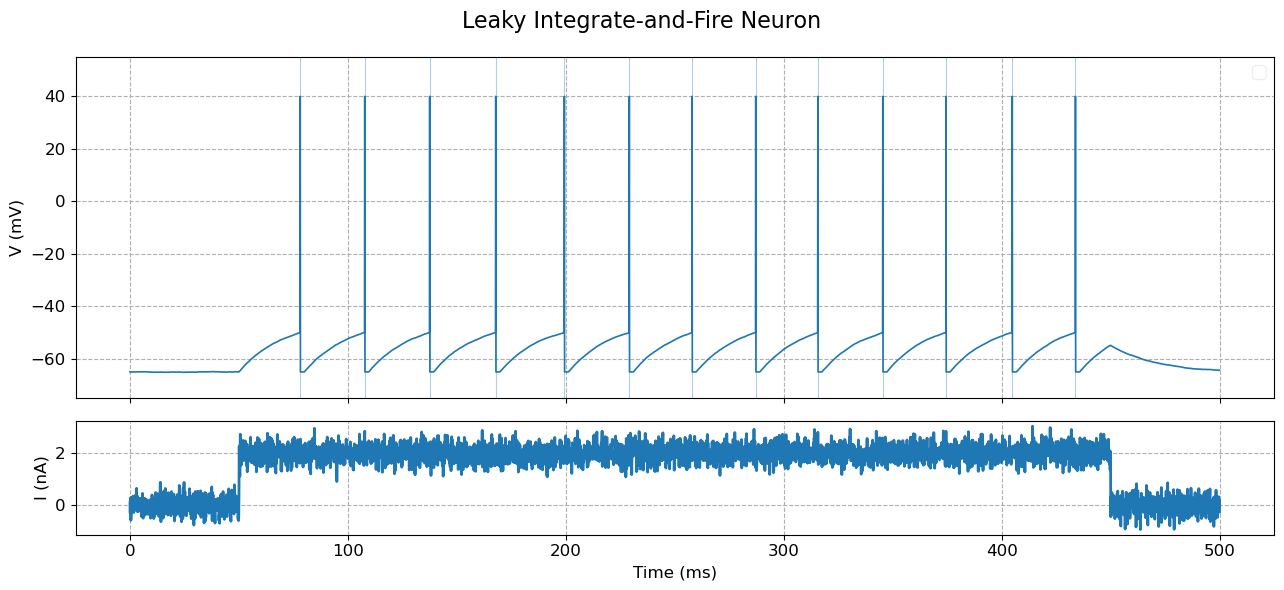

In [17]:
#Plot
plt.rcParams.update({'grid.linestyle':'--', 'axes.grid': True,
                      'lines.linewidth':  2, 'font.size': 12})

fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle('Leaky Integrate-and-Fire Neuron', fontsize=16)

ax[0].plot(time*1e3, V*1e3, lw=1.2)
ax[0].set_ylabel('V (mV)'); ax[0].legend(framealpha=0.3); ax[0].set_ylim(-75, 55)
for sp in spikes: ax[0].axvline(sp*1e3, alpha=0.35, lw=0.8)
ax[1].plot(time*1e3, I_ext*1e9)
ax[1].set_ylabel('I (nA)'); ax[1].set_xlabel('Time (ms)')
plt.tight_layout(); plt.show()